In [3]:
import torch

# 特征 (x1, x2)
X = torch.tensor([
    [2.0, 3.0],
    [3.0, 4.0],
    [1.5, 2.5],
    [3.5, 3.5],
    [2.5, 4.0],
    [0.5, 1.0],
    [1.0, 0.5],
    [0.0, 1.5],
    [1.0, 1.0],
    [0.5, 0.5]
], dtype=torch.float32)

# 标签：+1 表示正类，-1 表示负类（感知机常用 -1 / +1）
y = torch.tensor([1, 1, 1, 1, 1, -1, -1, -1, -1, -1], dtype=torch.float32)


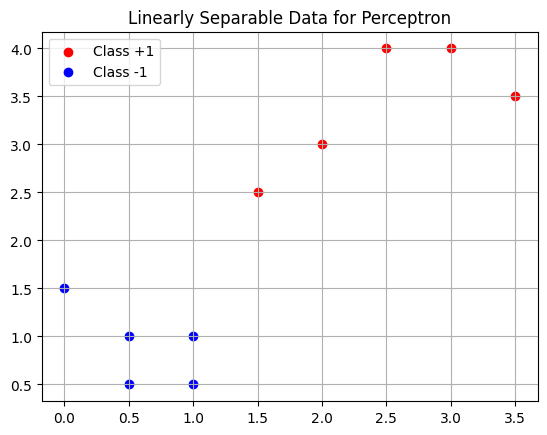

In [4]:
import matplotlib.pyplot as plt

plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Class +1')
plt.scatter(X[y == -1, 0], X[y == -1, 1], c='blue', label='Class -1')
plt.legend()
plt.grid(True)
plt.title('Linearly Separable Data for Perceptron')
plt.show()

In [2]:
# 感知机模型
def perceptron_fouction(x, w, b):
    if x.t@w+b > 0:
        return 1
    elif x.t@w+b == 0:
        return 0
    else:
        return -1

Epoch 1, 错误数: 4
Epoch 2, 错误数: 3
Epoch 3, 错误数: 0
已完全分类！


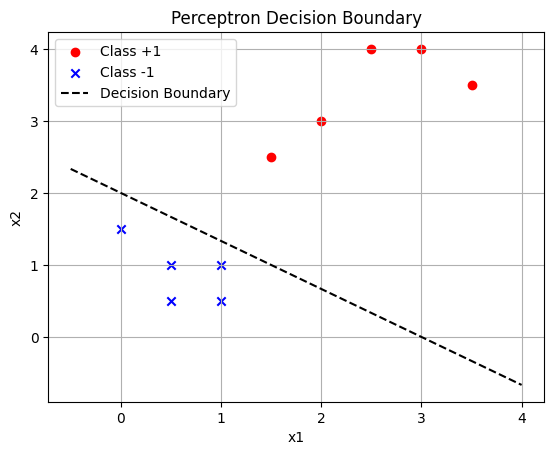

In [1]:
import torch
import matplotlib.pyplot as plt

# ----------------------------
# 1. 准备线性可分数据
# ----------------------------
X = torch.tensor([
    [2.0, 3.0],
    [3.0, 4.0],
    [1.5, 2.5],
    [3.5, 3.5],
    [2.5, 4.0],
    [0.5, 1.0],
    [1.0, 0.5],
    [0.0, 1.5],
    [1.0, 1.0],
    [0.5, 0.5]
], dtype=torch.float32)

y = torch.tensor([1, 1, 1, 1, 1, -1, -1, -1, -1, -1], dtype=torch.float32)

# ----------------------------
# 2. 感知机模型
# ----------------------------
class Perceptron:
    def __init__(self, n_features, lr=1.0):
        # 初始化权重和偏置（这里将偏置合并到权重中，通过在输入加一列1）
        self.lr = lr
        self.weights = torch.zeros(n_features + 1)  # w0 是偏置项

    def predict(self, X):
        # 添加偏置项：在每行前面加 1
        X_bias = torch.cat([torch.ones(X.shape[0], 1), X], dim=1)
        return torch.sign(X_bias @ self.weights)

    def train(self, X, y, epochs=10):
        for epoch in range(epochs):
            errors = 0
            for xi, yi in zip(X, y):
                # 添加偏置维度
                xi_bias = torch.cat([torch.tensor([1.0]), xi])
                pred = torch.sign(xi_bias @ self.weights)
                if pred != yi:
                    # 感知机更新规则: w ← w + lr * y_i * x_i
                    self.weights += self.lr * yi * xi_bias
                    errors += 1
            print(f"Epoch {epoch + 1}, 错误数: {errors}")
            if errors == 0:
                print("已完全分类！")
                break

# ----------------------------
# 3. 训练感知机
# ----------------------------
model = Perceptron(n_features=2, lr=1.0)
model.train(X, y, epochs=10)

# ----------------------------
# 4. 可视化结果
# ----------------------------
def plot_decision_boundary(model, X, y):
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', marker='o', label='Class +1')
    plt.scatter(X[y == -1, 0], X[y == -1, 1], c='blue', marker='x', label='Class -1')

    # 决策边界: w0 + w1*x1 + w2*x2 = 0 → x2 = -(w0 + w1*x1)/w2
    w0, w1, w2 = model.weights
    if w2 != 0:
        x1_vals = torch.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)
        x2_vals = -(w0 + w1 * x1_vals) / w2
        plt.plot(x1_vals, x2_vals, 'k--', label='Decision Boundary')
    
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.grid(True)
    plt.title('Perceptron Decision Boundary')
    plt.show()

plot_decision_boundary(model, X, y)